# Ocean in Motion · Annual temperature forecasting, 2026–2030

**Research question:** Can historical and geographic features improve 1–5 year predictions for known regions beyond simple references?

Target: annual regional sea surface temperature in °C. Inputs are versioned NOAA ERSSTv6 reconstructions, not direct local measurements. This notebook reviews the frozen experiment, including the comparison with persistence. It does not establish a validated climate projection.

The numerical pipeline is `python/ocean_pipeline/forecast.py`; dates, candidates and seed are fixed in `experiments/temperature/config.json`. Run the pipeline before this notebook. Data and code hashes identify the experiment.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
from IPython.display import display, SVG
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "experiments/temperature/config.json").exists())
sys.path.insert(0, str(ROOT / "python"))
from ocean_pipeline.forecast import Panel
panel = Panel(ROOT)
report = json.loads((ROOT / "reports/temperature/metrics.json").read_text())
config = json.loads((ROOT / "experiments/temperature/config.json").read_text())
print(f"Run {report['runId']} · {len(panel.ids)} regions × {len(panel.years)} years = {report['sourceRows']} source values")
print(f"{len(panel.excluded)} neighbor-imputed zones excluded from training/evaluation; derived predictions extend the timeline to all {len(panel.geometry)} regions.")
display(report['provenance'])

Run 5ed531b7bb3af8d8 · 82 regions × 44 years = 3608 source values
20 neighbor-imputed zones excluded from training/evaluation; derived predictions extend the timeline to all 102 regions.


{'inputs': {'src/data/seaTemperatures.json': '7c06bc7d7830f04ce379f915060f6c3558287dcb15b2f772b492f74ed79ae7fc',
  'src/data/caspianTemperatures.json': 'fe6283c9f63ce987ef299cccb89f241b8abc42045978336c7de6f1befab6d9fe',
  'src/data/seaAreas.geojson': '606396227da0e3c7efeada87dd7b0c99b570c989eb3f489a3c404408656c9b94',
  'src/data/caspian.geojson': 'fb97f2af302248636d3f04dcde4ee4d8efa00074bdeb0a2f77bad8ca6141c20b'},
 'configSha256': '72231c186ea496ae4791088121ca713f4f4222079910c92c78c3cbaa2f29ad5e',
 'codeSha256': 'b51ceff92aa23471a8980d3a6d9c485b6d5a5f2a513409c4b0e9424d27f6728c'}

## 1. Data audit and exploratory analysis

82 complete histories, 1982–2025. The 2° reconstruction has coarse regional coverage, rounded values and upstream estimation uncertainty. Regional observations are correlated; 3,608 values do not represent 3,608 independent measurements. Caspian is an inland region and receives no marine neighbor features.

The following diagnostic compares each region's first and last stored annual values; it is not an estimate of a causal climate trend.

,region,mean_C,sd_C,min_C,max_C,change_1982_to_2025_C
iho-bass-strait,Bass Strait,15.958,0.411,15.05,16.81,0.83
iho-great-australian-bight,Great Australian Bight,16.357,0.218,15.77,16.89,0.61
tasman,Tasman Sea,16.461,0.385,15.79,17.11,0.96
iho-mozambique-channel,Mozambique Channel,26.822,0.248,26.32,27.59,0.68
iho-timor-sea,Timor Sea,28.757,0.325,28.02,29.53,1.33
...,...,...,...,...,...,...
iho-laccadive-sea,Laccadive Sea,28.852,0.300,28.34,29.53,0.47
iho-skagerrak,Skagerrak,10.308,0.661,8.76,11.32,1.32
iho-norwegian-sea,Norwegian Sea,7.031,0.486,6.13,7.86,1.73
iho-gulf-of-guinea,Gulf of Guinea,27.991,0.337,27.30,28.62,0.93


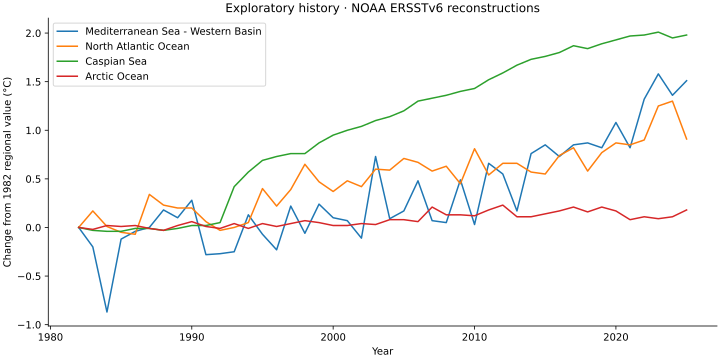

In [2]:
history = pd.DataFrame(panel.table).sort_index()
assert history.shape == (44, len(report["trainingAreas"]))
assert not history.isna().any().any()
audit = pd.DataFrame({"region": [panel.static[a]["name"] for a in history.columns], "mean_C": history.mean().values, "sd_C": history.std().values, "min_C": history.min().values, "max_C": history.max().values, "change_1982_to_2025_C": (history.loc[2025] - history.loc[1982]).values}, index=history.columns)
display(audit.round(3))
display(SVG(filename=str(ROOT / "reports/temperature/historical_trends.svg")))

## 2. Feature contract and neighbor ablation

Features use only information available at the origin: last three temperatures, five-year mean/slope/standard deviation, static polygon position and approximate surface, elapsed year, region indicators. Matching models are compared with and without inverse-distance neighbor features.

Neighbors mean geographic proximity, not verified water connection. Caspian is excluded from all marine neighbor lists. Learned models predict change from the origin, with one direct model per horizon. Scalers fit training rows only.

In [3]:
features = pd.read_csv(ROOT / "reports/temperature/features.csv")
display(features.head())
assert panel.neighbors["caspian"] == []
assert all("caspian" not in [a for a, _ in near] for near in panel.neighbors.values())
display(pd.DataFrame(json.loads((ROOT / "reports/temperature/geography.json").read_text()))[["areaId", "lat", "lon", "areaKm2", "neighbors"]].head())

,areaId,origin,temperature_t,temperature_t_minus_1,temperature_t_minus_2,mean_5y,trend_5y_c_per_year,std_5y,latitude,longitude_sin,longitude_cos,log_area_km2,origin_since_1982
0,arabian,1986,27.65,27.51,27.36,27.658,-0.091,0.210846,12.450060,0.892737,0.450579,15.248859,4
1,arctic,1986,-1.60,-1.61,-1.60,-1.614,0.007,0.014967,80.710870,-0.663278,-0.748373,15.460999,4
2,atlantic-north,1986,20.92,20.94,21.00,21.002,-0.036,0.084475,34.248285,-0.672091,0.740468,17.350575,4
3,atlantic-south,1986,16.87,16.83,16.87,16.790,0.052,0.083905,-30.052735,-0.283797,0.958885,17.511694,4
4,baltic,1986,8.05,7.52,8.56,8.316,-0.244,0.474325,56.751155,0.324147,0.946007,12.295761,4


,areaId,lat,lon,areaKm2,neighbors
0,arabian,12.450060,63.219174,4.192714e+06,"[[iho-laccadive-sea, 0.0006541490367047984], [..."
1,arctic,80.710870,-138.449662,5.183539e+06,"[[iho-beaufort-sea, 0.0010417144471258843], [i..."
2,atlantic-north,34.248285,-42.228662,3.429721e+07,"[[iho-gulf-of-st-lawrence, 0.00044355045788017..."
3,atlantic-south,-30.052735,-16.486928,4.029321e+07,"[[iho-gulf-of-guinea, 0.000236228647902689]]"
4,baltic,56.751155,18.913886,2.187657e+05,"[[iho-skagerrak, 0.0017838787150390367], [iho-..."


## 3. Temporal validation and leakage protection

| Stage | Origins | Target years | Purpose |
| --- | --- | --- | --- |
| Development | 2000–2009 | 2001–2014 | Select lowest pooled MAE |
| Calibration | 2014–2018 | 2015–2019 only | Frozen model, interval residuals |
| Final test | 2020 | 2021–2025 | Fixed-period re-evaluation |
| Publication | 2025 | 2026–2030 | Final history available |

Every region shares date cutoffs. Training labels satisfy `origin + horizon <= cutoff`. Development targets never overlap calibration or final test. Calibration/test results do not choose models or hyperparameters. Present-day historical reconstructions are used, rather than archived real-time vintages; this is a retrospective test.

The NOAA coverage audit expands the cohort while keeping dates and candidates fixed. This reuses the previously published test window; it is not a new untouched evaluation.


In [4]:
backtests = pd.read_csv(ROOT / "reports/temperature/backtests.csv")
dates = backtests.groupby("split").agg(min_origin=("origin", "min"), max_origin=("origin", "max"), first_target=("year", "min"), last_target=("year", "max"), rows=("year", "size"))
display(dates)
assert dates.loc["development", "last_target"] < dates.loc["calibration", "first_target"]
assert dates.loc["calibration", "last_target"] < dates.loc["test", "first_target"]
assert (backtests.origin < backtests.year).all()
display(pd.DataFrame(config["candidates"]).fillna(""))

,min_origin,max_origin,first_target,last_target,rows
split,,,,,
calibration,2014,2018,2015,2019,1230
development,2000,2009,2001,2014,32800
test,2020,2020,2021,2025,410


,id,family,neighbors,alpha,maxIter,maxLeafNodes,minSamplesLeaf,l2,learningRate
0,persistence,persistence,False,,,,,,
1,trend5,trend,False,,,,,,
2,ridge10,ridge,False,10.0,,,,,
3,ridge100,ridge,False,100.0,,,,,
4,ridge10_neighbors,ridge,True,10.0,,,,,
5,ridge100_neighbors,ridge,True,100.0,,,,,
6,boosting,boosting,False,,120.0,7.0,20.0,10.0,0.05
7,boosting_neighbors,boosting,True,,120.0,7.0,20.0,10.0,0.05


## 4. Model selection: development only

Eight fixed candidates: persistence, five-year linear trend, two Ridge strengths, fixed Histogram Gradient Boosting, and matching learned models with geographic neighbors. MAE determines selection; RMSE and bias support diagnosis. These comparisons are not uncertainty estimates or significance tests.

Added complexity and neighbor features must demonstrate improvement over simple references. The final test is not used to revise this list.

,id,mae,rmse,bias,n
0,boosting,0.2576,0.3413,0.0332,4100
1,persistence,0.2580,0.3491,-0.0525,4100
2,boosting_neighbors,0.2587,0.3423,0.0351,4100
3,ridge100,0.2722,0.3578,0.1005,4100
4,ridge100_neighbors,0.2733,0.3590,0.1021,4100
5,ridge10,0.2765,0.3628,0.1088,4100
6,ridge10_neighbors,0.2768,0.3631,0.1094,4100
7,trend5,0.3858,0.5459,-0.0120,4100


,model,without_neighbors_MAE,with_neighbors_MAE,difference_MAE
0,ridge10,0.2765,0.2768,0.0004
1,ridge100,0.2722,0.2733,0.0011
2,boosting,0.2576,0.2587,0.0010


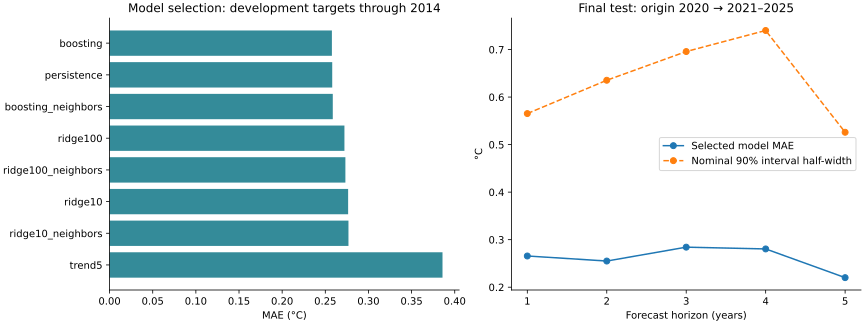

In [5]:
ranking = pd.DataFrame(report["developmentRanking"])[["id", "mae", "rmse", "bias", "n"]]
display(ranking.round(4))
assert report["selectedModel"]["id"] == ranking.iloc[0].id
ablation = []
for base in ["ridge10", "ridge100", "boosting"]:
    errors = ranking.set_index("id").mae
    ablation.append({"model": base, "without_neighbors_MAE": errors[base], "with_neighbors_MAE": errors[base + "_neighbors"], "difference_MAE": errors[base + "_neighbors"] - errors[base]})
display(pd.DataFrame(ablation).round(4))
display(SVG(filename=str(ROOT / "reports/temperature/model_comparison.svg")))

## 5. Fixed final test and interval calibration

The selected candidate is Histogram Gradient Boosting without neighbors. Its development MAE is only marginally lower than persistence; persistence performs better in the fixed final test. The metrics and nominal calibration below apply only to the 82 NOAA-derived histories; the other 20 regions have no locally validated errors or coverage. This does not imply that future temperatures will stay constant.

Nominal 90% intervals use an empirical absolute-error order statistic separately by horizon. Calibration pools correlated regional errors; the five-year horizon has one calibration origin and 82 regional errors. Future coverage is not guaranteed. Interval widths can be non-monotonic because dates and sample sizes differ. Reconstruction uncertainty is not fully captured.

Selected: boosting
Pooled final MAE: 0.261 °C; achieved coverage: 95.1%, versus nominal 90%.


,model,mae,rmse,bias,n
0,persistence,0.2492,0.3217,-0.0352,410
1,trend5,0.3376,0.4453,-0.0551,410


,mae,rmse,bias,coverage,meanIntervalWidth,calibrationN,n
1,0.2657,0.3450,0.2162,0.9146,1.1307,410.0,82.0
2,0.2550,0.3033,0.1362,0.9756,1.2709,328.0,82.0
3,0.2842,0.3365,0.1092,0.9634,1.3917,246.0,82.0
4,0.2805,0.3556,-0.0320,0.9634,1.4804,164.0,82.0
5,0.2201,0.2794,0.0918,0.9390,1.0520,82.0,82.0


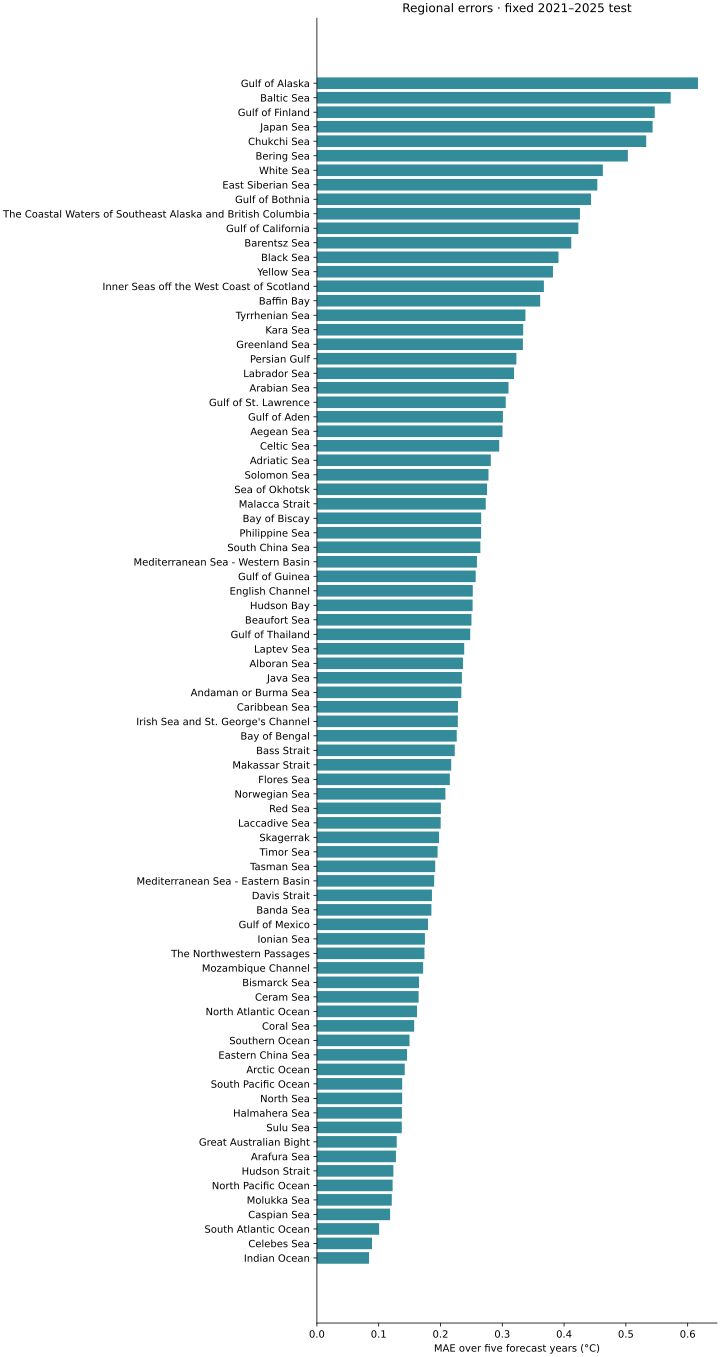

In [6]:
print("Selected:", report["selectedModel"]["id"])
display(pd.DataFrame([{"model": k, **v} for k, v in report["baselineHoldout"].items()]).round(4))
display(pd.DataFrame(report["byHorizon"]).T[["mae", "rmse", "bias", "coverage", "meanIntervalWidth", "calibrationN", "n"]].round(4))
print(f"Pooled final MAE: {report['holdout']['mae']:.3f} °C; achieved coverage: {report['holdout']['coverage']:.1%}, versus nominal 90%.")
display(SVG(filename=str(ROOT / "reports/temperature/regional_errors.svg")))

## 6. Published prediction contract and provenance

510 reviewed predictions: all 102 historical regions × five annual horizons, 2026–2030. The website reads this static artifact; it does not train in the browser. The 20 imputed zones retain their 2025 baseline plus the mean predicted change of their documented NOAA donors. They do not enter training or evaluation. Their transferred bounds are donor-derived ranges with no validated local coverage. One timeline and CSV show history and future together, with explicit row origins.

The selected model is reproduced from its pinned implementation, parameters, seed, cutoff, sources and run hashes; an opaque serialized model is unnecessary.

In [7]:
snapshot = json.loads((ROOT / "src/data/temperatureForecasts.json").read_text())
forecast = pd.DataFrame(snapshot["records"])
assert len(forecast) == 510
assert len(forecast[forecast.forecastBasis == "estimated-history"]) == len(report["derivedForecastAreas"])*5
assert len(forecast[forecast.intervalKind == "calibrated"]) == len(report["trainingAreas"])*5
assert sorted(forecast.year.unique()) == list(range(2026, 2031))
assert snapshot["runId"] == report["runId"]
assert (forecast.lower <= forecast.celsius).all() and (forecast.celsius <= forecast.upper).all()
display(forecast[forecast.areaId.isin(["med-west", "caspian", "iho-adriatic-sea", "iho-gulf-of-oman"])])
print("Cutoff:", snapshot["trainedThrough"], "· selected model:", snapshot["model"], "· run:", snapshot["runId"])

Cutoff: 2025 · selected model: boosting · run: 5ed531b7bb3af8d8


,areaId,year,horizon,celsius,lower,upper,forecastBasis,intervalKind,estimatedFrom
9,caspian,2026,1,16.172283,15.606941,16.737625,noaa-history,calibrated,[]
12,iho-adriatic-sea,2026,1,19.264788,18.699446,19.830130,noaa-history,calibrated,[]
47,iho-gulf-of-oman,2026,1,26.470538,25.905196,27.035880,estimated-history,donor-derived-range,"[arabian, iho-persian-gulf]"
94,med-west,2026,1,20.114890,19.549548,20.680232,noaa-history,calibrated,[]
111,caspian,2027,2,16.222000,15.586573,16.857426,noaa-history,calibrated,[]
114,iho-adriatic-sea,2027,2,19.388060,18.752634,20.023487,noaa-history,calibrated,[]
149,iho-gulf-of-oman,2027,2,26.594121,25.958694,27.229547,estimated-history,donor-derived-range,"[arabian, iho-persian-gulf]"
196,med-west,2027,2,20.308060,19.672634,20.943487,noaa-history,calibrated,[]
213,caspian,2028,3,16.292593,15.596755,16.988431,noaa-history,calibrated,[]
216,iho-adriatic-sea,2028,3,19.381170,18.685332,20.077008,noaa-history,calibrated,[]


## 7. Conclusion and limits

The coverage audit adds 60 NOAA-derived histories: 82 complete reconstructed histories now support training and evaluation, while 20 regions remain explicitly estimated. Gradient Boosting without neighbors wins development MAE narrowly (0.2576 versus 0.2580 °C for persistence). Its fixed 2021–2025 test MAE is 0.261 °C, versus 0.249 °C for persistence. Achieved pooled interval coverage is approximately 95%, against nominal 90%. The selected candidate follows the development rule; the tiny development advantage does not establish reliable superiority.

The NOAA cohort was expanded with no change to the fixed candidates, seed or temporal protocol. The existing final test window is re-evaluated; it is not a fresh untouched test. Main weaknesses remain coarse 2° reconstructions, dependent errors, current reconstruction vintages, one final five-year window, sparse five-year calibration, and no exogenous climate drivers or physical transport model. Geographic features do not establish causality. Predictions cannot establish local weather, species behavior or a verified climate scenario.

A next experiment should use more monthly/local data, independent vintages and explicit climate predictors, with a new predeclared protocol and fresh untouched evaluation period.

**Reproduction:** install `./python[forecast,analysis]`; run `ocean_pipeline.forecast --check`, `ocean_pipeline.forecast_analysis`, then `ocean_pipeline.execute_notebook`, all with `PYTHONPATH=python`. CI checks numerical drift and executes every code cell.

See [coverage audit](../reports/temperature/SOURCE_COVERAGE.md), [methodology](../docs/temperature-forecast.md), [generated report](../reports/temperature/REPORT.md), and the source hashes in `metrics.json`.
